# 06 — Financial Business Case

Business case based on Model 1 tier-level marginal effects (interaction logit).
Compares blanket rollout vs a configurable targeted rollout by segment variable and segment values (default: internet usage = Extreme).

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Targeting parameters (edit here)
SEGMENT_VARIABLE = "internet_usage"
TARGET_SEGMENT = "Extreme"

try:
    from helpers import load_analysis_data, prepare_model_data
    from config import (
        FINANCIAL_COLORS,
        MATPLOTLIB_THEME,
        FIGURE_HEIGHT,
        BAR_EDGE_COLOR,
        FONT_SIZE_TITLE,
        FONT_SIZE_LABEL_MD,
        FONT_COLOR_ANNOTATION,
    )
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    sys.path.append(str((Path.cwd() / "notebooks").resolve()))
    from helpers import load_analysis_data, prepare_model_data
    from config import (
        FINANCIAL_COLORS,
        MATPLOTLIB_THEME,
        FIGURE_HEIGHT,
        BAR_EDGE_COLOR,
        FONT_SIZE_TITLE,
        FONT_SIZE_LABEL_MD,
        FONT_COLOR_ANNOTATION,
    )

plt.rcParams.update(MATPLOTLIB_THEME)

df = load_analysis_data()
df_clean = prepare_model_data(df)

In [2]:
formula_interaction = (
    "churned ~ has_booster * C(internet_usage) + age + tenure + "
    "C(tv_product) + C(mobile_product) + C(commune)"
)
fit = smf.logit(formula=formula_interaction, data=df_clean).fit(disp=False)

f1 = df_clean.copy(); f0 = df_clean.copy()
f1["has_booster"] = 1; f0["has_booster"] = 0
ite = fit.predict(f1) - fit.predict(f0)
df_clean["ite_churn"] = ite

tier_effects = df_clean.groupby(SEGMENT_VARIABLE, observed=True)["ite_churn"].mean()
tier_fin = tier_effects.to_frame(name="mean")
tier_fin["prevented_rate"] = (-tier_fin["mean"]).clip(lower=0.0)

N_CUSTOMERS_TOTAL = 1_500_000
VALUE_PER_PREVENTED_CHURN = 1800.0
BOOSTER_COST = 35.0

segment_mix = df_clean[SEGMENT_VARIABLE].value_counts(normalize=True).sort_index()
tier_fin["mix"] = segment_mix
tier_fin["population"] = tier_fin["mix"] * N_CUSTOMERS_TOTAL
tier_fin["revenue_saved_chf"] = tier_fin["population"] * tier_fin["prevented_rate"] * VALUE_PER_PREVENTED_CHURN
tier_fin["cost_chf"] = tier_fin["population"] * BOOSTER_COST
tier_fin["net_roi_chf"] = tier_fin["revenue_saved_chf"] - tier_fin["cost_chf"]

blanket_cost = float(tier_fin["cost_chf"].sum())
blanket_saved = float(tier_fin["revenue_saved_chf"].sum())
blanket_net = blanket_saved - blanket_cost

available_segments = set(tier_fin.index.astype(str))
if TARGET_SEGMENT not in available_segments:
    raise ValueError(
        f"Target segment '{TARGET_SEGMENT}' not found for {SEGMENT_VARIABLE}. "
        f"Available: {sorted(available_segments)}"
    )

targeted = tier_fin.loc[[TARGET_SEGMENT]].copy()
target_cost = float(targeted["cost_chf"].sum())
target_saved = float(targeted["revenue_saved_chf"].sum())
target_net = target_saved - target_cost

target_scenario_label = f"Targeted ({SEGMENT_VARIABLE}: {TARGET_SEGMENT})"

print("Blanket rollout:")
print(f"  Cost: CHF {blanket_cost:,.0f}")
print(f"  Saved revenue: CHF {blanket_saved:,.0f}")
print(f"  Net: CHF {blanket_net:,.0f}")

print(f"\n{target_scenario_label}:")
print(f"  Cost: CHF {target_cost:,.0f}")
print(f"  Saved revenue: CHF {target_saved:,.0f}")
print(f"  Net: CHF {target_net:,.0f}")

if target_net > blanket_net:
    print("\nRecommendation: Targeted rollout dominates blanket rollout.")
else:
    print("\nRecommendation: Blanket rollout is at least as good as targeted rollout.")

Blanket rollout:
  Cost: CHF 52,500,000
  Saved revenue: CHF 30,536,976
  Net: CHF -21,963,024

Targeted (internet_usage: Extreme):
  Cost: CHF 8,693,580
  Saved revenue: CHF 29,362,645
  Net: CHF 20,669,065

Recommendation: Targeted rollout dominates blanket rollout.


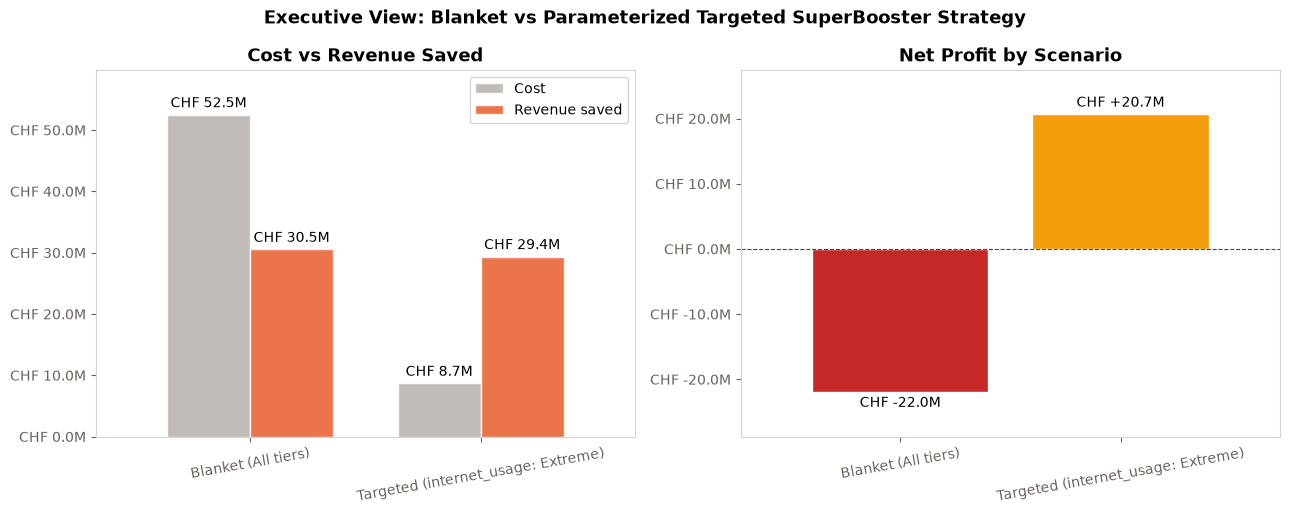

In [3]:
scenario_df = pd.DataFrame({
    "scenario": ["Blanket (All tiers)", target_scenario_label],
    "cost_chf": [blanket_cost, target_cost],
    "saved_chf": [blanket_saved, target_saved],
    "net_chf": [blanket_net, target_net],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Grouped bars for cost and saved revenue (side-by-side per scenario)
x = np.arange(len(scenario_df))
bar_width = 0.36
cost_vals = scenario_df["cost_chf"].to_numpy()
saved_vals = scenario_df["saved_chf"].to_numpy()

cost_bars = axes[0].bar(
    x - bar_width / 2,
    cost_vals,
    width=bar_width,
    alpha=0.85,
    label="Cost",
    color=FINANCIAL_COLORS["cost"],
    edgecolor=BAR_EDGE_COLOR,
)
saved_bars = axes[0].bar(
    x + bar_width / 2,
    saved_vals,
    width=bar_width,
    alpha=0.85,
    label="Revenue saved",
    color=FINANCIAL_COLORS["saved"],
    edgecolor=BAR_EDGE_COLOR,
)
axes[0].set_title("Cost vs Revenue Saved", fontsize=FONT_SIZE_TITLE, fontweight="bold", color=FONT_COLOR_ANNOTATION)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenario_df["scenario"], rotation=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
axes[0].legend()
axes[0].margins(x=0.18, y=0.14)
axes[0].bar_label(
    cost_bars,
    labels=[f"CHF {val/1e6:.1f}M" for val in cost_vals],
    padding=3,
    fontsize=FONT_SIZE_LABEL_MD,
    color=FONT_COLOR_ANNOTATION,
)
axes[0].bar_label(
    saved_bars,
    labels=[f"CHF {val/1e6:.1f}M" for val in saved_vals],
    padding=3,
    fontsize=FONT_SIZE_LABEL_MD,
    color=FONT_COLOR_ANNOTATION,
)

colors = [FINANCIAL_COLORS["net_negative"] if val < 0 else FINANCIAL_COLORS["net_positive"] for val in scenario_df["net_chf"]]
bars = axes[1].bar(
    scenario_df["scenario"],
    scenario_df["net_chf"],
    color=colors,
    edgecolor=BAR_EDGE_COLOR,
)
axes[1].axhline(0, color=FINANCIAL_COLORS["reference"], linewidth=0.8, linestyle="--")
axes[1].set_title("Net Profit by Scenario", fontsize=FONT_SIZE_TITLE, fontweight="bold", color=FONT_COLOR_ANNOTATION)
axes[1].tick_params(axis="x", rotation=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
axes[1].margins(x=0.18, y=0.16)
axes[1].bar_label(
    bars,
    labels=[f"CHF {val/1e6:+.1f}M" for val in scenario_df["net_chf"]],
    padding=3,
    fontsize=FONT_SIZE_LABEL_MD,
    color=FONT_COLOR_ANNOTATION,
)

fig.suptitle("Executive View: Blanket vs Parameterized Targeted SuperBooster Strategy", fontsize=FONT_SIZE_TITLE, fontweight="bold", color=FONT_COLOR_ANNOTATION)
plt.tight_layout()
plt.show()